In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv("../data/clean/airbnbnyc_cleaned.csv")
df.head(20)

,name,host_id,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,price,maximum_nights,availability_365,number_of_reviews,calculated_host_listings_count,reviews_per_month,total_amenities
0,Superfast Wi-Fi. Clean & quiet home by the park,2787,False,Kensington,Brooklyn,40.645290,-73.972380,Private room in condo,Private room,2,1.0,285.0,730,347,9,6,0.08,761
1,Skylit Midtown Manhattan Spacious Studio,2845,False,Midtown,Manhattan,40.753560,-73.985590,Entire rental unit,Entire home/apt,1,0.0,240.0,1125,312,49,3,0.26,553
2,Spacious Family Friendly Duplex w/ Patio + Yard,7378,False,Sunset Park,Brooklyn,40.662650,-73.994540,Entire townhouse,Entire home/apt,4,2.0,215.0,730,80,4,1,0.03,816
3,Only 2 stops to Manhattan studio,15991,True,Williamsburg,Brooklyn,40.709350,-73.953420,Entire rental unit,Entire home/apt,3,2.0,97.0,120,219,196,1,1.00,384
4,UES Beautiful Blue Room,16800,False,East Harlem,Manhattan,40.787780,-73.947590,Private room in rental unit,Private room,1,2.0,63.0,120,254,253,1,1.33,364
5,"Perfect for Your Parents, With Garden & Patio",17571,True,Fort Greene,Brooklyn,40.691940,-73.973890,Private room in guest suite,Private room,2,1.0,246.0,1125,4,413,2,2.20,1017
6,Convenient 3BR w/6 beds!!,204539,False,Ridgewood,Queens,40.702710,-73.899300,Entire rental unit,Entire home/apt,9,3.0,223.0,730,365,4,10,0.03,371
7,SpaHa Studio Monthly Rental,292204,True,East Harlem,Manhattan,40.792667,-73.946533,Entire rental unit,Entire home/apt,2,1.0,125.0,60,227,196,4,1.14,661
8,"Bright, High Ceiling, Spacious & Cozy 1BR - En...",292630,True,East Village,Manhattan,40.725980,-73.979780,Entire rental unit,Entire home/apt,6,1.0,150.0,1125,362,168,6,0.95,708
9,Great room in great location,297176,False,Harlem,Manhattan,40.803710,-73.956350,Private room in rental unit,Private room,1,1.0,77.0,480,180,2,2,0.02,303


Describe numerical data

In [3]:
df.describe()

,host_id,latitude,longitude,accommodates,bedrooms,price,maximum_nights,availability_365,number_of_reviews,calculated_host_listings_count,reviews_per_month,total_amenities
count,2.145900e+04,21459.000000,21459.000000,21459.000000,21459.000000,21459.000000,21459.000000,21459.000000,21459.000000,21459.000000,21459.000000,21459.000000
mean,2.091221e+08,40.727775,-73.944380,2.890023,1.341116,521.528356,464.162776,245.644205,35.545319,84.881076,0.799522,542.227830
std,2.018163e+08,0.059228,0.060472,2.045280,0.970509,3501.384801,397.233750,106.924975,80.932657,234.721884,1.946193,302.452586
min,1.678000e+03,40.500366,-74.251907,1.000000,0.000000,8.000000,1.000000,0.000000,0.000000,1.000000,0.000000,2.000000
25%,2.512704e+07,40.685615,-73.983615,2.000000,1.000000,89.000000,120.000000,167.000000,0.000000,1.000000,0.000000,310.000000
50%,1.213795e+08,40.728090,-73.954070,2.000000,1.000000,154.000000,365.000000,270.000000,5.000000,3.000000,0.200000,499.000000
75%,4.073020e+08,40.763410,-73.922245,4.000000,2.000000,270.000000,730.000000,342.000000,37.000000,20.000000,0.920000,734.000000
max,7.005911e+08,40.905919,-73.711822,16.000000,15.000000,50184.000000,3000.000000,365.000000,3277.000000,1054.000000,121.970000,2069.000000


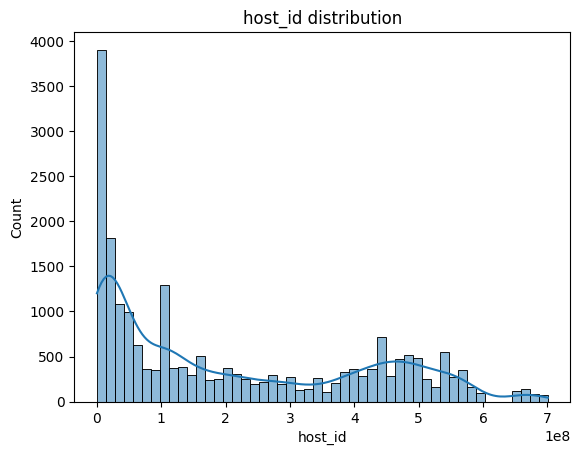

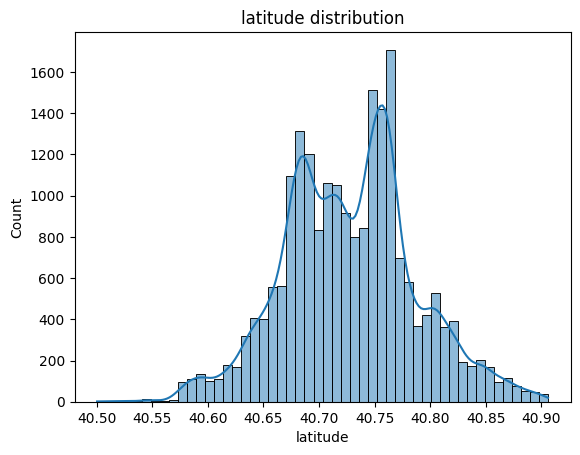

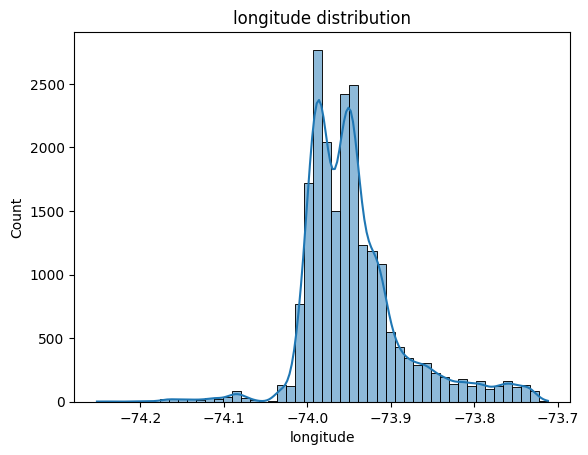

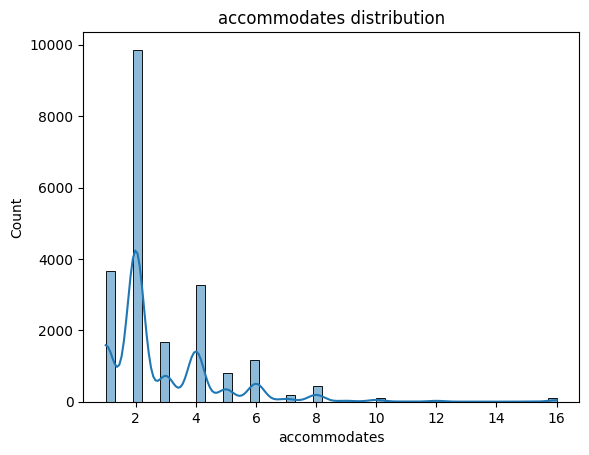

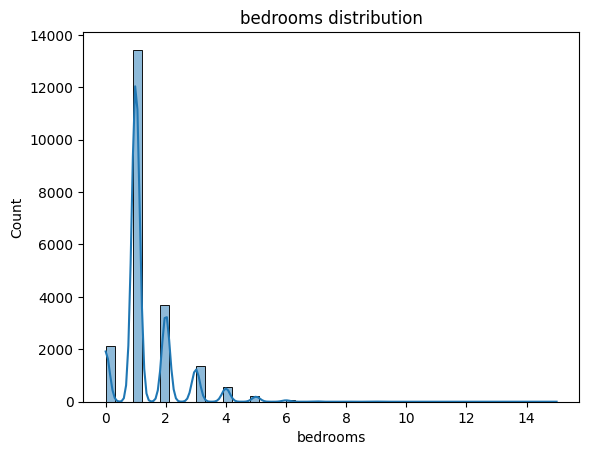

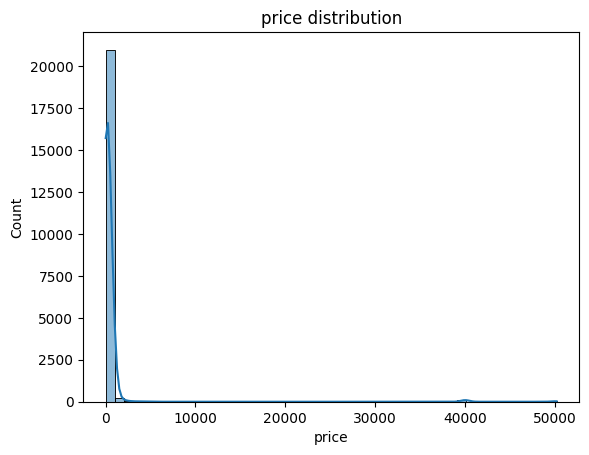

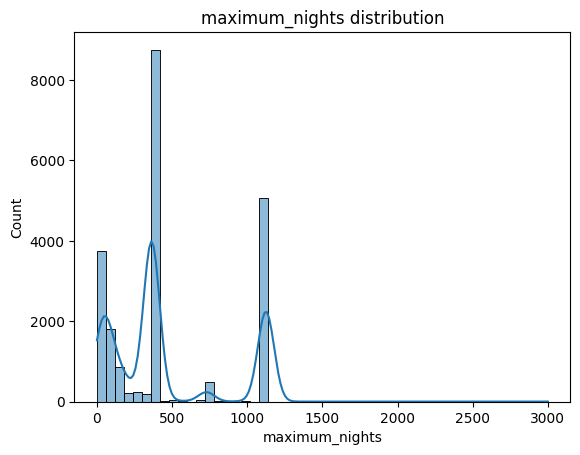

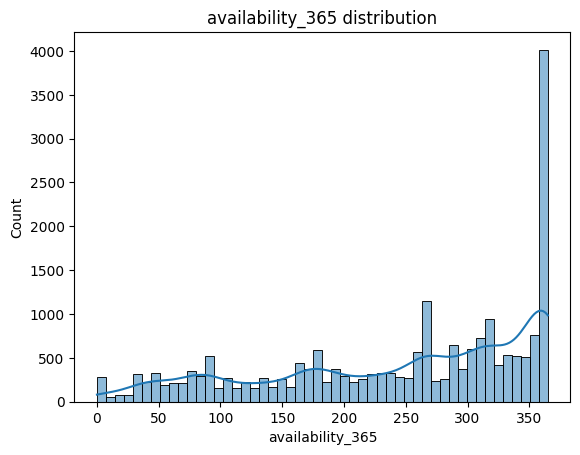

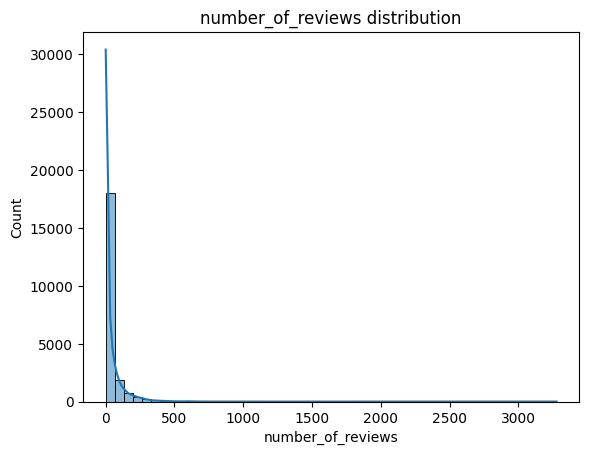

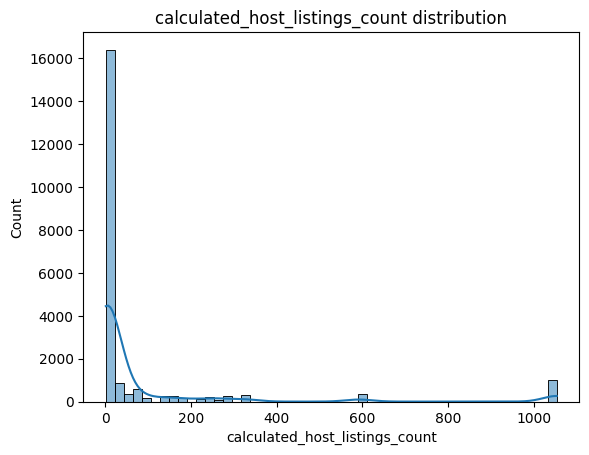

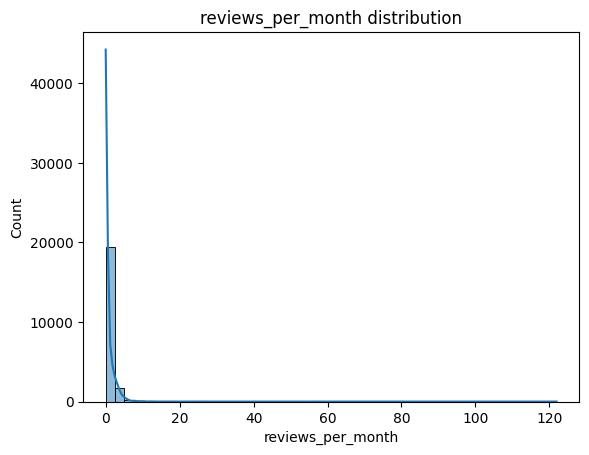

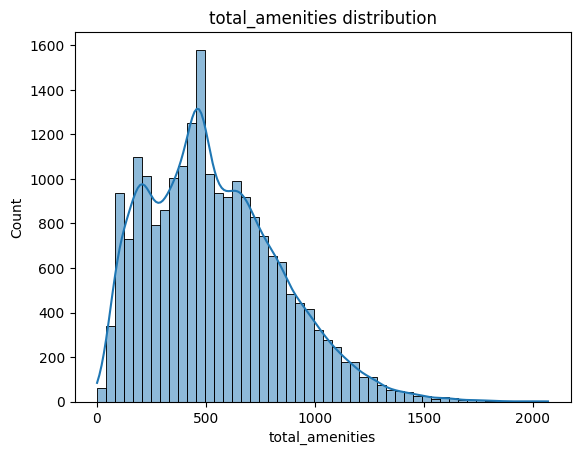

In [4]:
numerical_cols=['host_id','latitude','longitude','accommodates','bedrooms','price','maximum_nights','availability_365','number_of_reviews','calculated_host_listings_count','reviews_per_month','total_amenities']
for col in numerical_cols:
    sns.histplot(df[col], bins=50,kde=True)
    plt.title(f'{col} distribution')
    plt.show()    

# Describe Categorical columns

In [5]:
df.describe(include=['O'])

,name,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,property_type,room_type
count,21459,21459,21459,21459,21459,21459
unique,20615,3,222,5,61,4
top,Wyndham Midtown 45 | 2BR/2BA King Bed Suite,False,Midtown,Manhattan,Entire rental unit,Entire home/apt
freq,15,15314,1364,9543,9363,12287


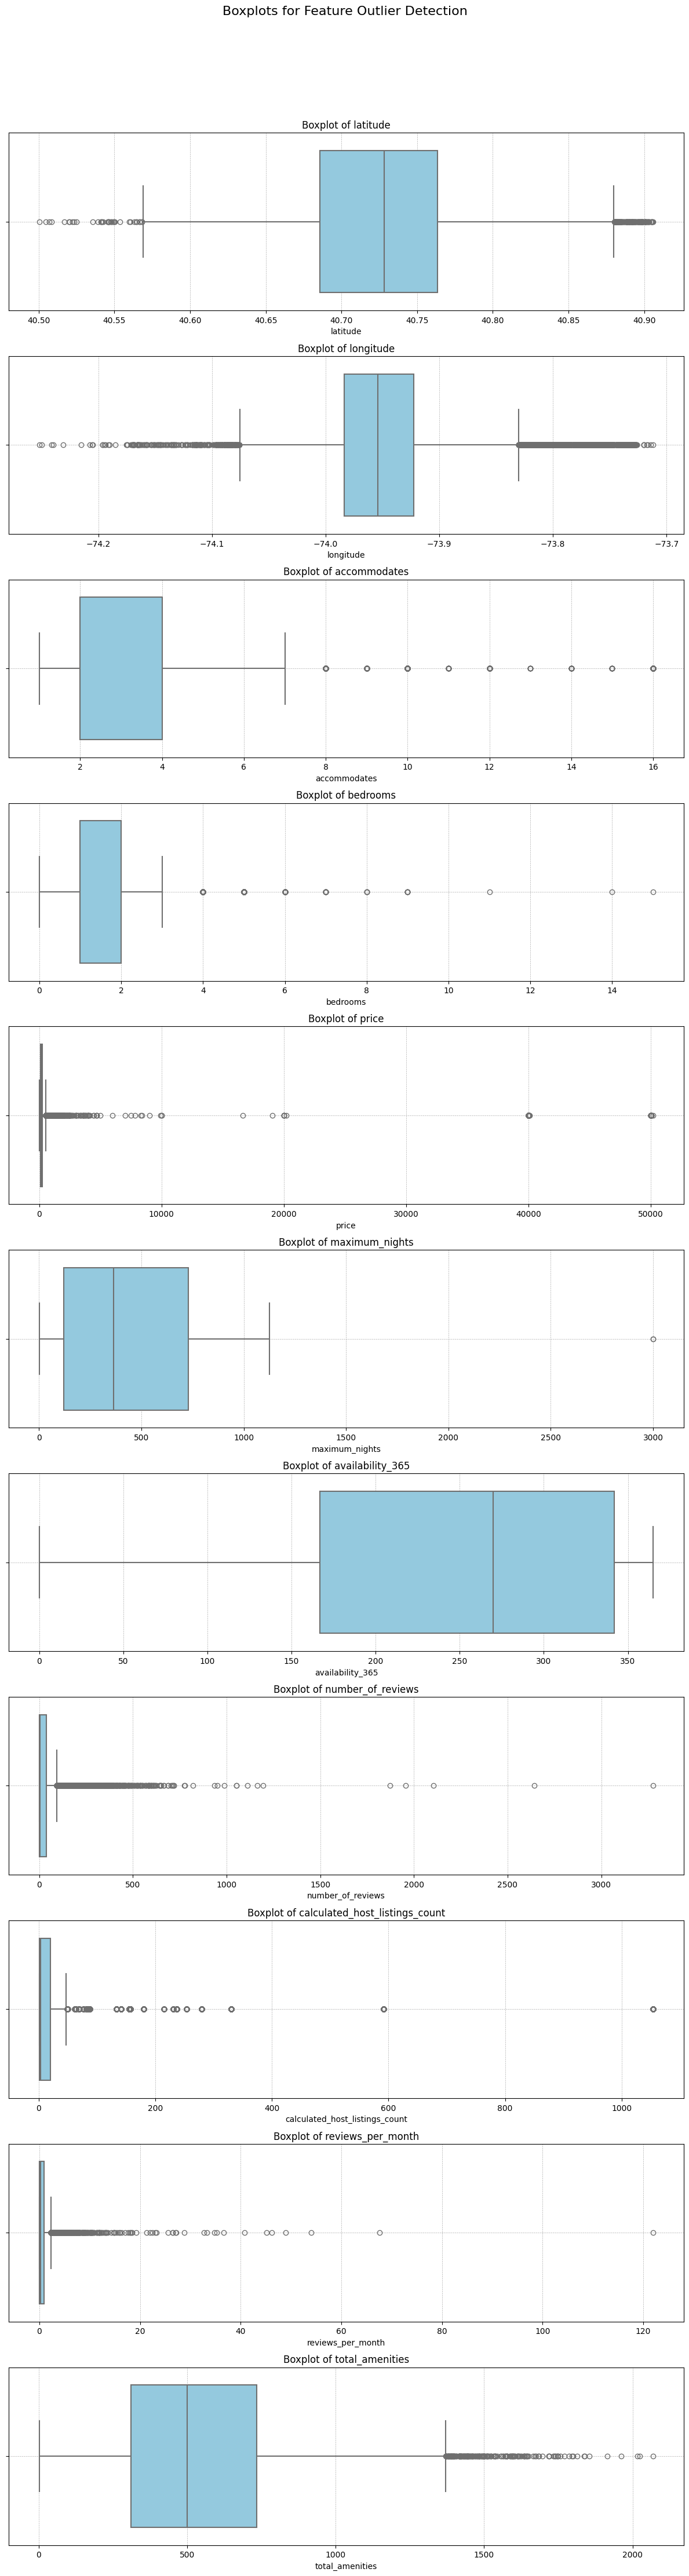

In [6]:

# Exclude name,id and categorical columns to detect outliers
features = df.columns.drop(['name','host_id','host_is_superhost','neighbourhood_cleansed','neighbourhood_group_cleansed','property_type','room_type'])

# Set up the figure
plt.figure(figsize=(12, len(features) * 4))  # Adjust height based on number of features

# Loop through features to plot one boxplot per row
for i, col in enumerate(features, 1):
    plt.subplot(len(features), 1, i)
    sns.boxplot(x=df[col], color='skyblue', linewidth=1.5)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.grid(True, linestyle='--', linewidth=0.5)

plt.suptitle("Boxplots for Feature Outlier Detection", fontsize=16, y=1.01)
plt.tight_layout()
plt.subplots_adjust(top=0.96)  # Add spacing for suptitle
plt.show()

In [7]:
df.shape

(21459, 18)

removing outliers in 'price'

In [8]:
df = df[df['price'] <= 750]

In [9]:
df.shape

(20679, 18)

Boxplot of Price

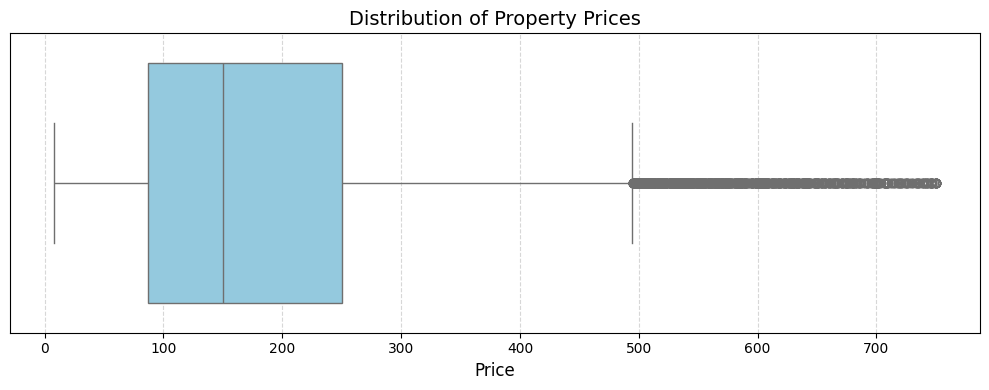

In [10]:
plt.figure(figsize=(10, 4)) 

sns.boxplot(x=df['price'], color='skyblue')

plt.title('Distribution of Property Prices', fontsize=14)
plt.xlabel('Price', fontsize=12)
plt.yticks([]) 
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

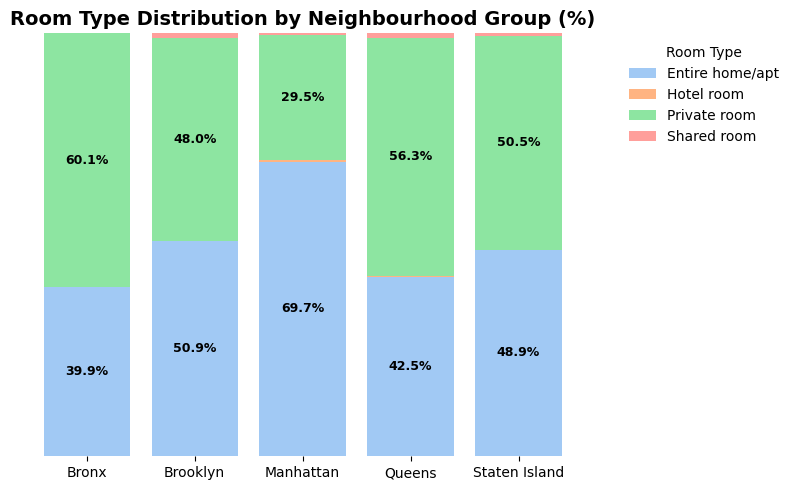

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Prepare percentage data ---
counts = df.groupby(['neighbourhood_group_cleansed', 'room_type']).size().reset_index(name='count')

# Calculate percentage within each neighbourhood group (aligned index)
counts['percentage'] = counts.groupby('neighbourhood_group_cleansed')['count'] \
                             .transform(lambda x: 100 * x / x.sum())

# Pivot for stacked plotting
pivot_df = counts.pivot_table(
    index='neighbourhood_group_cleansed',
    columns='room_type',
    values='percentage',
    fill_value=0
)

# Colors
colors = sns.color_palette("pastel", n_colors=len(pivot_df.columns))

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
bottom_val = pd.Series([0] * len(pivot_df), index=pivot_df.index)

for i, room_type in enumerate(pivot_df.columns):
    bars = ax.bar(
        pivot_df.index,
        pivot_df[room_type],
        bottom=bottom_val,
        label=room_type,
        color=colors[i]
    )
    # Add percentage labels
    for bar, perc in zip(bars, pivot_df[room_type]):
        if perc > 3:  # Only show if it's big enough
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{perc:.1f}%",
                ha='center', va='center',
                fontsize=9, color='black', weight='bold'
            )
    bottom_val += pivot_df[room_type]

# Style
ax.set_ylim(0, 100)
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
sns.despine(left=True, bottom=True, right=True, top=True)
ax.set_title("Room Type Distribution by Neighbourhood Group (%)", weight='bold', fontsize=14)
ax.legend(title="Room Type", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()


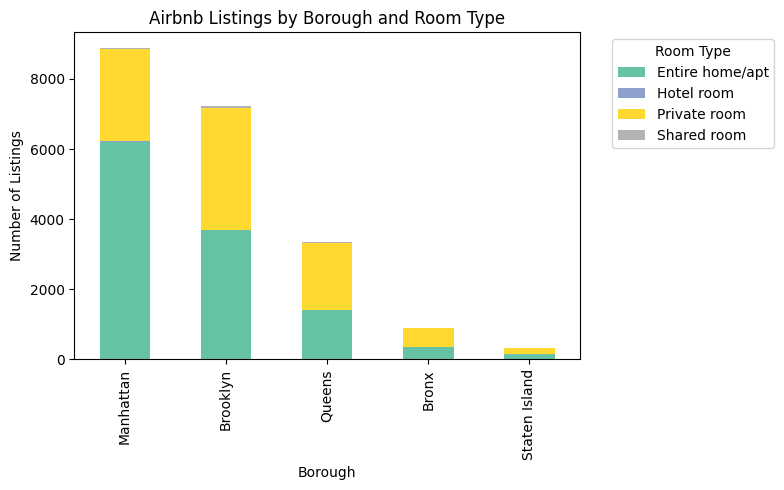

In [12]:


# --- Group and calculate ---
counts = df.groupby(['neighbourhood_group_cleansed', 'room_type']).size().reset_index(name='count')

# Pivot for stacked bar plot (absolute counts)
pivot_df = counts.pivot(index='neighbourhood_group_cleansed', columns='room_type', values='count').fillna(0)

# Sort by total listings
pivot_df['total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by='total', ascending=False)

# Plot
pivot_df.drop(columns='total').plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')

plt.ylabel('Number of Listings')
plt.xlabel('Borough')
plt.title('Airbnb Listings by Borough and Room Type')
plt.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


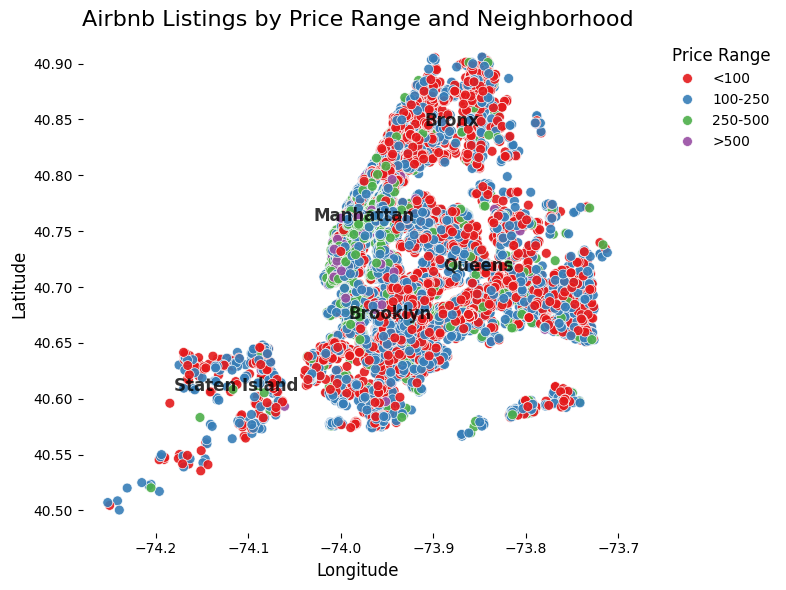

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Bin Airbnb prices
bins = [0, 100, 250, 500, df['price'].max()]
labels = ['<100', '100-250', '250-500', '>500']
df['price_bin'] = pd.cut(df['price'], bins=bins, labels=labels, include_lowest=True)

# ---------- Plot ----------
plt.figure(figsize=(8, 6), facecolor='none')  # Transparent figure
ax = plt.gca()
ax.set_facecolor('none')                       # Transparent axes

# Scatter plot
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='price_bin',
    palette='Set1',
    alpha=0.9,
    s=50,
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)

# Remove spines and grid
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Annotate neighborhood names at their centroid
neigh_centroids = df.groupby('neighbourhood_group_cleansed')[['longitude', 'latitude']].mean()
for name, row in neigh_centroids.iterrows():
    ax.text(
        row['longitude'], 
        row['latitude'], 
        name, 
        fontsize=12, 
        weight='bold', 
        color='black', 
        ha='center', 
        va='center',
        alpha=0.8
    )

# Titles and labels
plt.title('Airbnb Listings by Price Range and Neighborhood', fontsize=16, color='black')
plt.xlabel('Longitude', fontsize=12, color='black')
plt.ylabel('Latitude', fontsize=12, color='black')

# Legend
plt.legend(
    title='Price Range',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False,
    fontsize=10,
    title_fontsize=12
)

plt.tight_layout()

plt.show()

# Cleanup
df.drop(['price_bin'], axis=1, inplace=True)


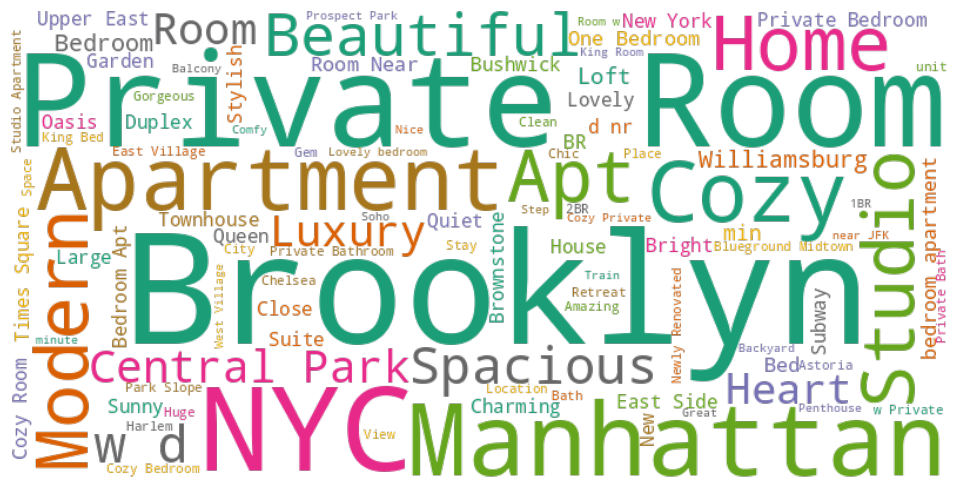

In [14]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load your data
df1 = pd.read_csv("../data/clean/airbnbnyc_cleaned.csv")  # Replace with your file path

# Combine all descriptions into a single text
text = " ".join(desc for desc in df1['name'].dropna().astype(str))

# Optional: remove common words that are not informative
stopwords = set(WordCloud().stopwords)
custom_stopwords = {"the", "and", "a", "of", "to", "in", "with", "for"}  # add more if needed
stopwords = stopwords.union(custom_stopwords)

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color=None,  # transparent background
    mode="RGBA",            # needed for transparency
    stopwords=stopwords,
    colormap="Dark2",
    max_words=100
).generate(text)

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout()
plt.show()


In [15]:
#Dropping columns name,host_id,neighbourhood_cleansed,property_type as part of feature engineering
df.drop(['name','host_id','neighbourhood_cleansed','property_type'],axis=1,inplace=True)

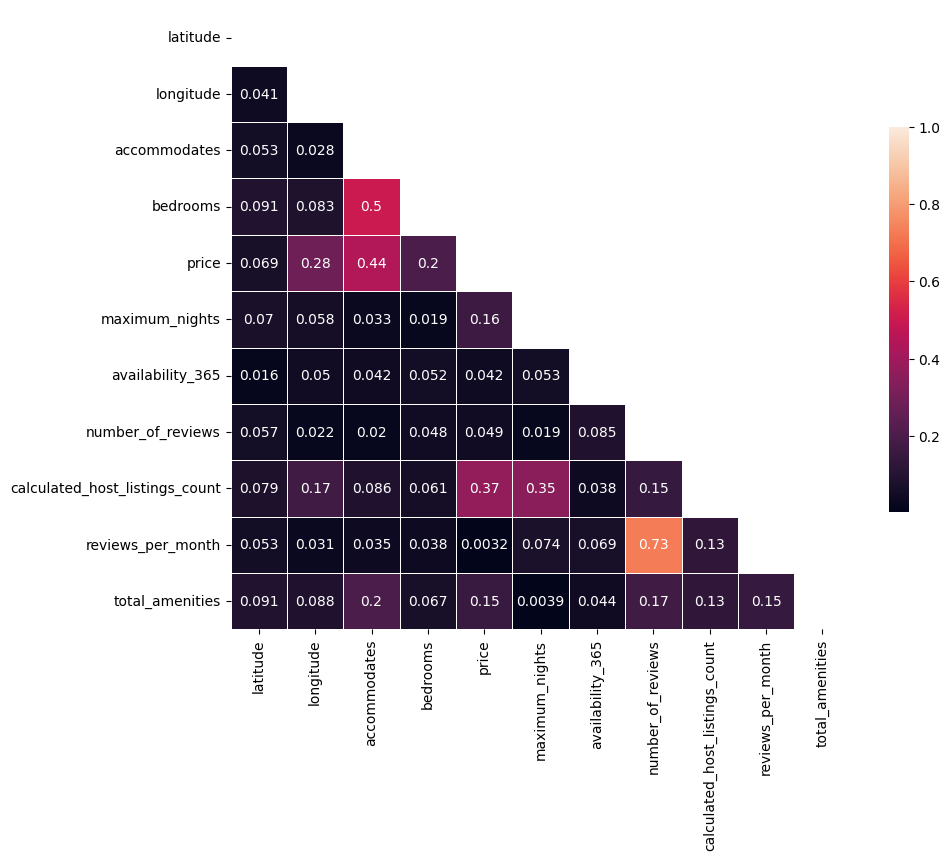

In [16]:
corr=np.abs(df.corr(numeric_only=True))

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

plt.show()

Deleteing reviews_per_month because of the high correlation with number_of_reviews

In [17]:
df.drop(['reviews_per_month'],axis=1,inplace=True)

number_of_reviews                 9.589348
calculated_host_listings_count    3.443436
accommodates                      2.310073
bedrooms                          1.745347
price                             1.421049
longitude                         0.989363
maximum_nights                    0.840389
total_amenities                   0.631750
latitude                          0.104251
availability_365                 -0.616443
dtype: float64


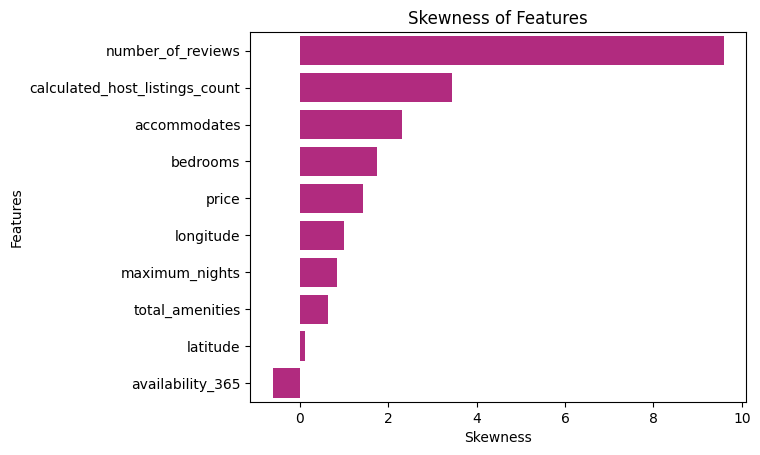

In [18]:
features = df.select_dtypes(include='number')  # Only numeric columns
skew_values = features.skew().sort_values(ascending=False)
print(skew_values)

sns.barplot(x=skew_values.values,color="#C71585", y=skew_values.index)
plt.title("Skewness of Features")
plt.xlabel("Skewness")
plt.ylabel("Features")
plt.show()

In [19]:
def transform_skewed_features(df, skew_threshold=2):
    df_transformed = df.copy()
    
    # Select only numeric columns
    numeric_cols = df.select_dtypes(include='number')
    
    # Calculate skewness
    skewness = numeric_cols.skew().sort_values(ascending=False)
    
    # Identify highly skewed columns
    skewed_cols = skewness[skewness > skew_threshold].index.tolist()

    print(f"Transforming {len(skewed_cols)} highly skewed columns (skew > {skew_threshold}):")
    for col in skewed_cols:
        if (df_transformed[col] < 0).any():
            print(f"⚠️ Skipped '{col}' (contains negative values)")
            continue
        print(f"✔ Transforming '{col}' (original skew: {skewness[col]:.2f})")
        df_transformed[col] = np.log1p(df_transformed[col])
    
    return df_transformed
df_cleaned = transform_skewed_features(df)


Transforming 3 highly skewed columns (skew > 2):
✔ Transforming 'number_of_reviews' (original skew: 9.59)
✔ Transforming 'calculated_host_listings_count' (original skew: 3.44)
✔ Transforming 'accommodates' (original skew: 2.31)


In [20]:
df_cleaned.to_csv('../data/clean/airbnbnyc_final.csv', index=False)

In [21]:
df_cleaned.shape

(20679, 13)